#We build a custom multi-branch CNN with naive Inception module from scratch and train it on the Indoor Scenes CVPR 2019 dataset.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1: Load image paths and labels from TrainImages.txt and TestImages.txt


In [2]:
rootDir = '/kaggle/input/indoor-scenes-cvpr-2019/indoorCVPR_09/Images'


with open('/kaggle/input/indoor-scenes-cvpr-2019/TrainImages.txt', 'r') as f:
    trainList = [line.strip() for line in f.readlines()]

with open('/kaggle/input/indoor-scenes-cvpr-2019/TestImages.txt', 'r') as f:
    testList = [line.strip() for line in f.readlines()]

def getLabelFromPath(path):
    return path.split('/')[0]
    
trainFull = [(os.path.join(rootDir, x), getLabelFromPath(x)) for x in trainList]
testFull = [(os.path.join(rootDir, x), getLabelFromPath(x)) for x in testList]

# 80-10-10 split: stratified
trainData, tempData = train_test_split(trainFull, test_size=0.2, stratify=[y for _, y in trainFull], random_state=42)
valData, testData = train_test_split(tempData, test_size=0.5, stratify=[y for _, y in tempData], random_state=42)

# Create label mapping
labelNames = sorted(set([label for _, label in trainFull]))
labelToIndex = {label: idx for idx, label in enumerate(labelNames)}
classNames = labelNames

print(f"Loaded: Train = {len(trainData)}, Val = {len(valData)}, Test = {len(testData)}")

Loaded: Train = 4288, Val = 536, Test = 536


## 2: Create custom PyTorch Dataset using parsed image-label pairs


In [3]:
labelNames = sorted(set([label for _, label in trainFull]))
labelToIndex = {label: idx for idx, label in enumerate(labelNames)}

trainTransform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


class SceneDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        imgPath, label = self.data[idx]
        image = Image.open(imgPath).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, labelToIndex[label]


## 3: Create DataLoaders for training, validation, and testing


In [4]:
batchSize = 32

trainDataset = SceneDataset(trainData, trainTransform)
valDataset = SceneDataset(valData, transform)
testDataset = SceneDataset(testFull, transform)

trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
valLoader = DataLoader(valDataset, batch_size=batchSize, shuffle=False)
testLoader = DataLoader(testDataset, batch_size=batchSize, shuffle=False)

classNames = labelNames


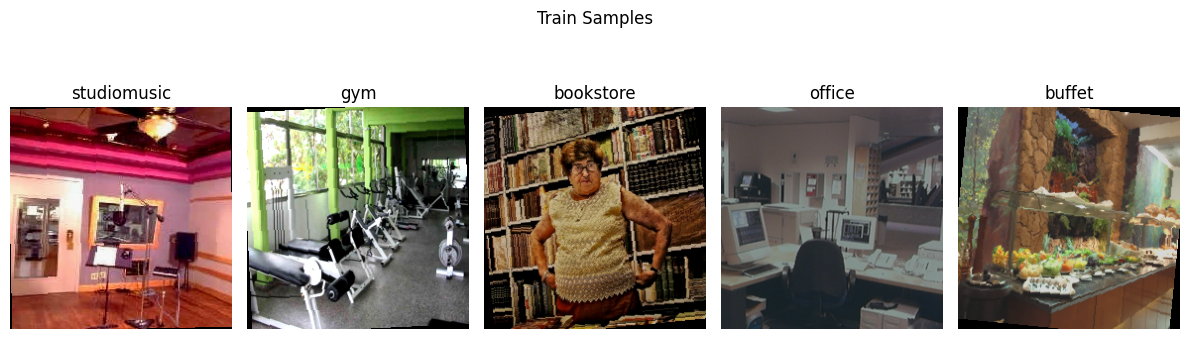

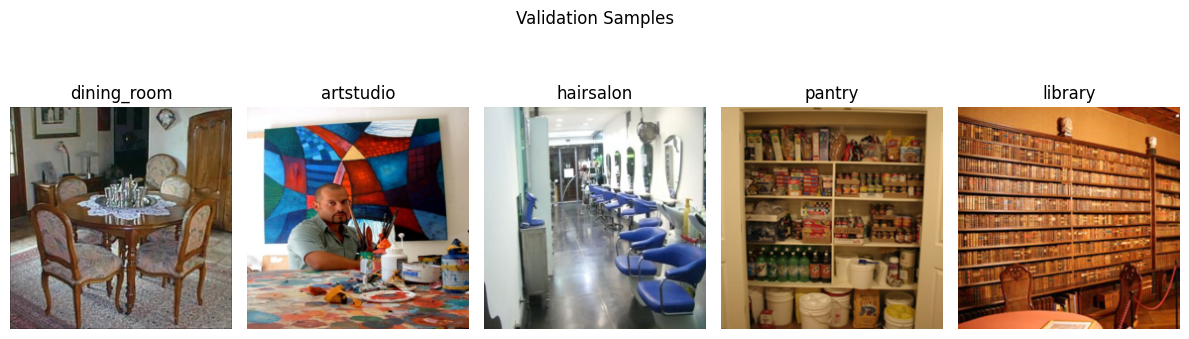

In [5]:

def showSamples(dataLoader, classNames, title="Sample Images"):
    images, labels = next(iter(dataLoader))
    plt.figure(figsize=(12, 4))
    for i in range(5):
        img = images[i].permute(1, 2, 0).numpy()  # Convert CHW → HWC
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Unnormalize
        img = np.clip(img, 0, 1)
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(classNames[labels[i].item()])
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

showSamples(trainLoader, classNames, title="Train Samples")
showSamples(valLoader, classNames, title="Validation Samples")


## 4: Define the custom multi-branch CNN using bottleneck Inception block


In [6]:
import torch
import torch.nn as nn

class InceptionBlockOptimized(nn.Module):
    def __init__(self, inChannels, outChannels=128):
        super(InceptionBlockOptimized, self).__init__()
        assert outChannels % 4 == 0  # for equal split
        branch_channels = outChannels // 4

        self.branch1x1 = nn.Sequential(
            nn.Conv2d(inChannels, branch_channels, kernel_size=1),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True)
        )
        self.branch3x3 = nn.Sequential(
            nn.Conv2d(inChannels, branch_channels, kernel_size=1),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(branch_channels, branch_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True)
        )
        self.branch5x5 = nn.Sequential(
            nn.Conv2d(inChannels, branch_channels, kernel_size=1),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(branch_channels, branch_channels, kernel_size=5, padding=2),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True)
        )
        self.branchPool = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(inChannels, branch_channels, kernel_size=1),
            nn.BatchNorm2d(branch_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return torch.cat([
            self.branch1x1(x),
            self.branch3x3(x),
            self.branch5x5(x),
            self.branchPool(x)
        ], dim=1)

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels)
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.block(x))

class CustomInceptionCNN(nn.Module):
    def __init__(self, numClasses):
        super(CustomInceptionCNN, self).__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),  # smaller conv
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.inception1 = InceptionBlockOptimized(64, 128)
        self.inception2 = InceptionBlockOptimized(128, 256)
        self.inception3 = InceptionBlockOptimized(256, 256)

        self.residual1 = ResidualBlock(256)
        self.residual2 = ResidualBlock(256)

        self.globalAvgPool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(256, numClasses)
        )

        self._initWeights()

    def _initWeights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.inception3(x)
        x = self.residual1(x)
        x = self.residual2(x)
        x = self.globalAvgPool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [7]:
from torchinfo import summary

model = CustomInceptionCNN(numClasses=67)
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
CustomInceptionCNN                       [1, 67]                   --
├─Sequential: 1-1                        [1, 64, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─BatchNorm2d: 2-2                  [1, 64, 224, 224]         128
│    └─ReLU: 2-3                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-4                    [1, 64, 112, 112]         --
├─InceptionBlockOptimized: 1-2           [1, 128, 112, 112]        --
│    └─Sequential: 2-5                   [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                  [1, 32, 112, 112]         2,080
│    │    └─BatchNorm2d: 3-2             [1, 32, 112, 112]         64
│    │    └─ReLU: 3-3                    [1, 32, 112, 112]         --
│    └─Sequential: 2-6                   [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-4                  [1, 32, 112, 112]         2,080
│    

5: Setup device, loss function, optimizer, LR scheduler, and early stopping

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CustomInceptionCNN(numClasses=len(classNames)).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
earlyStopPatience = 5


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [9]:
def trainModel(model, trainLoader, valLoader, criterion, optimizer, scheduler, epochs=50, earlyStopPatience=5):
    bestValAcc = 0
    patienceCounter = 0

    trainAccList, valAccList, trainLossList, valLossList = [], [], [], []

    for epoch in range(epochs):
        model.train()
        totalTrainLoss, correctTrain, totalTrain = 0, 0, 0

        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            totalTrainLoss += loss.item()
            _, preds = outputs.max(1)
            correctTrain += (preds == labels).sum().item()
            totalTrain += labels.size(0)

        trainAcc = correctTrain / totalTrain
        trainLoss = totalTrainLoss / len(trainLoader)

        valLoss, valAcc = evaluateModel(model, valLoader, criterion)

        trainAccList.append(trainAcc)
        valAccList.append(valAcc)
        trainLossList.append(trainLoss)
        valLossList.append(valLoss)

        scheduler.step(valLoss)

        print(f"Epoch {epoch+1:02d} | Train Acc: {trainAcc:.4f} | Val Acc: {valAcc:.4f} | "
              f"Train Loss: {trainLoss:.4f} | Val Loss: {valLoss:.4f}")

        if valAcc > bestValAcc:
            bestValAcc = valAcc
            patienceCounter = 0
            torch.save(model.state_dict(), "bestModel.pth")
        else:
            patienceCounter += 1
            if patienceCounter >= earlyStopPatience:
                print("Early stopping triggered.")
                break

    return trainAccList, valAccList, trainLossList, valLossList


In [12]:
trainAccList, valAccList, trainLossList, valLossList = trainModel(
    model, trainLoader, valLoader, criterion, optimizer, scheduler,
    epochs=50, earlyStopPatience=5
)


Epoch 01 | Train Acc: 0.0648 | Val Acc: 0.1157 | Train Loss: 3.9895 | Val Loss: 3.7750
Epoch 02 | Train Acc: 0.0798 | Val Acc: 0.1213 | Train Loss: 3.8983 | Val Loss: 3.7261
Epoch 03 | Train Acc: 0.0926 | Val Acc: 0.1381 | Train Loss: 3.8278 | Val Loss: 3.6513
Epoch 04 | Train Acc: 0.1185 | Val Acc: 0.1586 | Train Loss: 3.7214 | Val Loss: 3.5930
Epoch 05 | Train Acc: 0.1236 | Val Acc: 0.1791 | Train Loss: 3.6666 | Val Loss: 3.4962
Epoch 06 | Train Acc: 0.1367 | Val Acc: 0.1847 | Train Loss: 3.5928 | Val Loss: 3.4420
Epoch 07 | Train Acc: 0.1472 | Val Acc: 0.1791 | Train Loss: 3.5586 | Val Loss: 3.4781
Epoch 08 | Train Acc: 0.1691 | Val Acc: 0.2295 | Train Loss: 3.4848 | Val Loss: 3.3235
Epoch 09 | Train Acc: 0.1719 | Val Acc: 0.2034 | Train Loss: 3.4573 | Val Loss: 3.3815
Epoch 10 | Train Acc: 0.1735 | Val Acc: 0.2015 | Train Loss: 3.4446 | Val Loss: 3.4032
Epoch 11 | Train Acc: 0.1971 | Val Acc: 0.2500 | Train Loss: 3.3942 | Val Loss: 3.2472
Epoch 12 | Train Acc: 0.1891 | Val Acc: 0.2

In [11]:

def evaluateModel(model, dataLoader, criterion):
    model.eval()
    totalLoss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            totalLoss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avgLoss = totalLoss / len(dataLoader)
    accuracy = correct / total
    return avgLoss, accuracy

In [13]:
model.load_state_dict(torch.load("bestModel.pth"))
testLoss, testAcc = evaluateModel(model, testLoader, criterion)
print(f"Test Accuracy: {testAcc:.4f} | Test Loss: {testLoss:.4f}")

Test Accuracy: 0.3239 | Test Loss: 2.9560


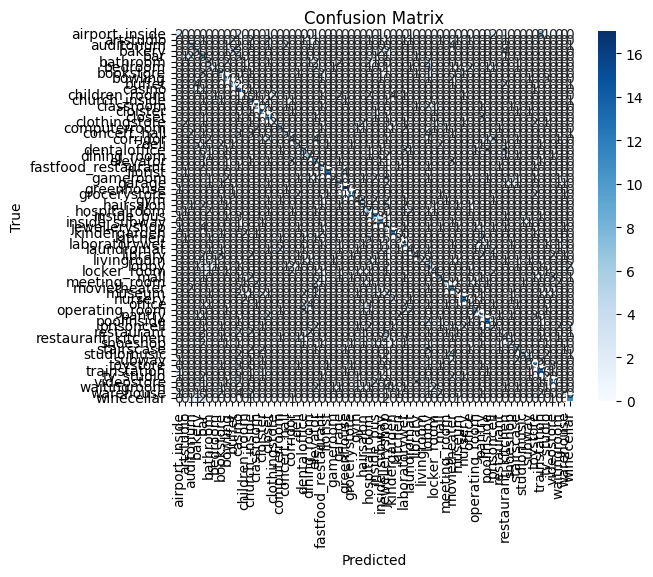

                     precision    recall  f1-score   support

     airport_inside       0.22      0.10      0.14        20
          artstudio       0.00      0.00      0.00        20
         auditorium       0.38      0.28      0.32        18
             bakery       0.26      0.26      0.26        19
                bar       0.16      0.44      0.23        18
           bathroom       0.15      0.17      0.16        18
            bedroom       0.25      0.05      0.08        21
          bookstore       0.33      0.40      0.36        20
            bowling       0.40      0.50      0.44        20
             buffet       0.50      0.50      0.50        20
             casino       0.23      0.79      0.36        19
      children_room       0.11      0.06      0.07        18
      church_inside       0.24      0.42      0.30        19
          classroom       0.56      0.50      0.53        18
           cloister       0.56      0.70      0.62        20
             closet    

In [14]:
allLabels, allPreds = [], []
model.eval()
with torch.no_grad():
    for images, labels in testLoader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        allLabels.extend(labels.cpu().numpy())
        allPreds.extend(preds.cpu().numpy())

cm = confusion_matrix(allLabels, allPreds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classNames, yticklabels=classNames, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(allLabels, allPreds, target_names=classNames))